## NLP con Sklearn

In [ ]:
!pip install wordcloud

#### 1. Bag of Words

In [1]:
import os
os.getcwd()

'C:\\Users\\tomas\\ML\\Master Data Science and AI\\10 NLP'

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

# Crear un conjunto de textos
corpus = [
    "El sol brilla en el cielo",
    "Las estrellas iluminan la noche",
    "El cielo es azul"
]

# Inicializar el CountVectorizer
vectorizer = CountVectorizer()

# Transformar el texto en matriz de frecuencias
X_counts = vectorizer.fit_transform(corpus)

#  Obtener el vocabulario generado
print("Vocabulario:", vectorizer.get_feature_names_out())

#  Mostrar la matriz en formato denso
print(X_counts.toarray())


Vocabulario: ['azul' 'brilla' 'cielo' 'el' 'en' 'es' 'estrellas' 'iluminan' 'la' 'las'
 'noche' 'sol']
[[0 1 1 2 1 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 1 1 1 1 0]
 [1 0 1 1 0 1 0 0 0 0 0 0]]


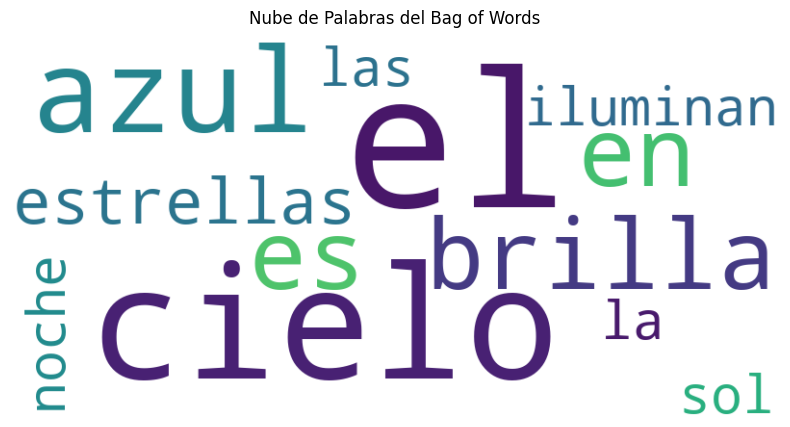

In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#  Sumar todas las ocurrencias de palabras en Bag of Words
word_freq = dict(zip(vectorizer.get_feature_names_out(), X_counts.sum(axis=0).A1))

#  Generar la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)

#  Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Eliminar ejes para mejor visualización
plt.title("Nube de Palabras del Bag of Words")
plt.show()


#### 2. Bigram

Vocabulario: ['brilla en' 'cielo es' 'el cielo' 'el sol' 'en el' 'es azul'
 'estrellas iluminan' 'iluminan la' 'la noche' 'las estrellas'
 'sol brilla']
[[1 0 1 1 1 0 0 0 0 0 1]
 [0 0 0 0 0 0 1 1 1 1 0]
 [0 1 1 0 0 1 0 0 0 0 0]]


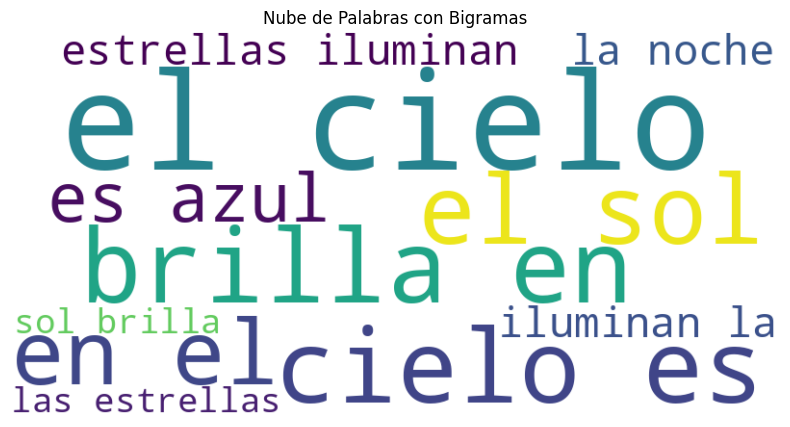

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#  Crear un conjunto de textos
corpus = [
    "El sol brilla en el cielo",
    "Las estrellas iluminan la noche",
    "El cielo es azul"
]

#  Inicializar el CountVectorizer con bigramas
vectorizer = CountVectorizer(ngram_range=(2,2))

#  Transformar el texto en matriz de frecuencias
X_counts = vectorizer.fit_transform(corpus)

#  Sumar todas las ocurrencias de cada bigrama
bigram_freq = dict(zip(vectorizer.get_feature_names_out(), X_counts.sum(axis=0).A1))

print("Vocabulario:", vectorizer.get_feature_names_out())

#  Mostrar la matriz en formato denso
print(X_counts.toarray())


#  Generar la nube de palabras con bigramas
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(bigram_freq)

#  Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # 🔹 Eliminar ejes para mejor visualización
plt.title("Nube de Palabras con Bigramas")
plt.show()


#### 3. TF-IDF

In [6]:
tfidf_freq

{'azul': 0.5628290964997665,
 'brilla': 0.4119729784338903,
 'cielo': 0.7413621039523244,
 'el': 1.0546781728415304,
 'en': 0.4119729784338903,
 'es': 0.5628290964997665,
 'estrellas': 0.4472135954999579,
 'iluminan': 0.4472135954999579,
 'la': 0.4472135954999579,
 'las': 0.4472135954999579,
 'noche': 0.4472135954999579,
 'sol': 0.4119729784338903}

Vocabulario: ['azul' 'brilla' 'cielo' 'el' 'en' 'es' 'estrellas' 'iluminan' 'la' 'las'
 'noche' 'sol']
[[0.         0.41197298 0.31331607 0.62663214 0.41197298 0.
  0.         0.         0.         0.         0.         0.41197298]
 [0.         0.         0.         0.         0.         0.
  0.4472136  0.4472136  0.4472136  0.4472136  0.4472136  0.        ]
 [0.5628291  0.         0.42804604 0.42804604 0.         0.5628291
  0.         0.         0.         0.         0.         0.        ]]


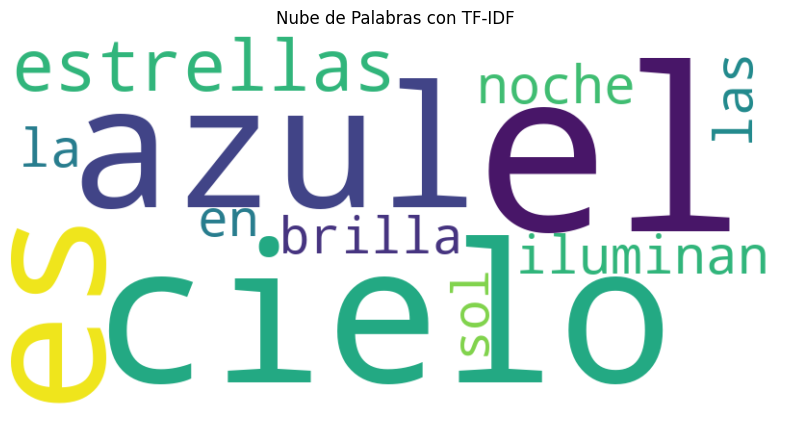

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#  Crear un conjunto de textos
corpus = [
    "El sol brilla en el cielo",
    "Las estrellas iluminan la noche",
    "El cielo es azul"
]

#  Inicializar el TfidfVectorizer
vectorizer = TfidfVectorizer()

#  Transformar el texto en matriz TF-IDF
X_tfidf = vectorizer.fit_transform(corpus)

#  Obtener pesos de las palabras
tfidf_freq = dict(zip(vectorizer.get_feature_names_out(), X_tfidf.sum(axis=0).A1))

print("Vocabulario:", vectorizer.get_feature_names_out())

#  Mostrar la matriz en formato denso
print(X_tfidf.toarray())


#  Generar la nube de palabras basada en TF-IDF
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(tfidf_freq)

#  Mostrar la nube de palabras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # 🔹 Eliminar ejes para mejor visualización
plt.title("Nube de Palabras con TF-IDF")
plt.show()


#### 4. One Hot Encoder

Para poder aplicar la funcion "One hot encoder" debemos primeramente tokenizar. Es mas eficiente emplear CountVectorizer(binary=True) que ya determina 1 o 0 si la palabra aparece o no.

In [11]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Corpus de frases
corpus = [
    "El sol brilla en el cielo",
    "Las estrellas iluminan la noche",
    "El cielo es azul"
]

# Vectorizador tipo Bag of Words binario
vectorizer = CountVectorizer(binary=True)

# Ajustar y transformar
X = vectorizer.fit_transform(corpus)

# Obtener vocabulario
vocabulario = vectorizer.get_feature_names_out()

# Convertir a DataFrame
df_encoded = pd.DataFrame(X.toarray(), columns=vocabulario)

print("\n**One-Hot Encoding por palabra:**\n")
print(df_encoded)



**One-Hot Encoding por palabra:**

   azul  brilla  cielo  el  en  es  estrellas  iluminan  la  las  noche  sol
0     0       1      1   1   1   0          0         0   0    0      0    1
1     0       0      0   0   0   0          1         1   1    1      1    0
2     1       0      1   1   0   1          0         0   0    0      0    0


Nube de palabras. Wordcloud, dado un extge es capaz de contar la aparcion total de cada una de las palabras y con esto pinta cada tamaño de palabra segun frecuencia absoluta de aparición.

C:\Users\tomas\ML\nlp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


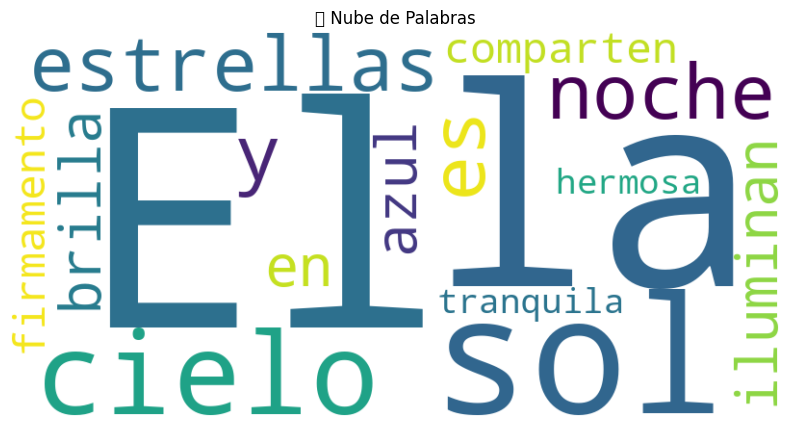

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Texto base (puede ser un corpus más grande)
texto = """
El sol brilla en el cielo. Las estrellas iluminan la noche. El cielo es azul.
El sol y las estrellas comparten el firmamento. La noche es tranquila y hermosa.
"""

# Crear la nube de palabras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",  # Puedes cambiar el estilo de colores
    max_words=100
).generate(texto)

# Mostrar la nube
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("🌌 Nube de Palabras")
plt.show()
